In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import zscore

In [90]:
countries = ["ethiopia", "kenya", "tanzania", "nigeria", "sudan"]



Processing: ethiopia

Summary stats:


,t2m,t2m_max,t2m_min,prectotcorr
count,4108.00000,4108.000000,4108.000000,4108.000000
mean,16.06850,23.199175,10.227544,3.633795
std,1.89805,2.751471,2.607256,6.289061
min,10.03000,15.650000,1.170000,0.000000
25%,14.82000,21.110000,8.417500,0.020000
50%,16.04000,22.740000,10.990000,0.820000
75%,17.36000,25.170000,12.220000,4.580000
max,21.53000,30.930000,15.680000,82.300000


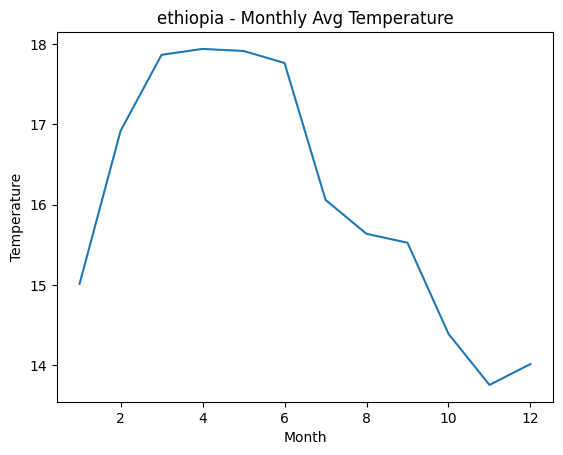

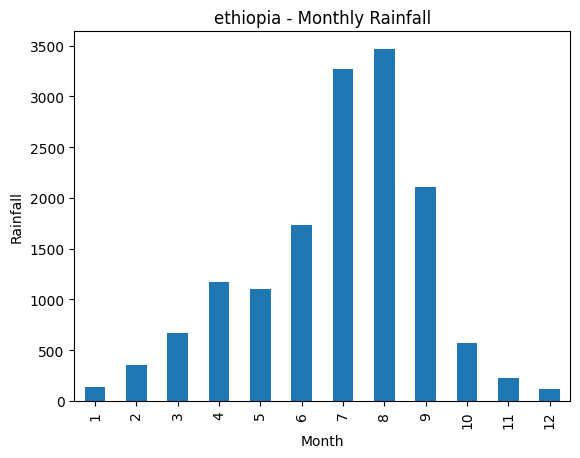


Outliers detected:


t2m             3
t2m_max         0
t2m_min        18
prectotcorr    95
rh2m           13
ws2m            3
dtype: int64


Processing: kenya

Summary stats:


,t2m,t2m_max,t2m_min,prectotcorr
count,4108.000000,4108.000000,4108.000000,4108.000000
mean,20.427600,27.838717,14.673169,1.468162
std,1.440824,2.358770,1.415691,3.180228
min,15.260000,18.880000,8.970000,0.000000
25%,19.460000,26.297500,13.700000,0.100000
50%,20.360000,27.875000,14.750000,0.380000
75%,21.400000,29.520000,15.750000,1.360000
max,25.400000,34.270000,18.750000,51.650000


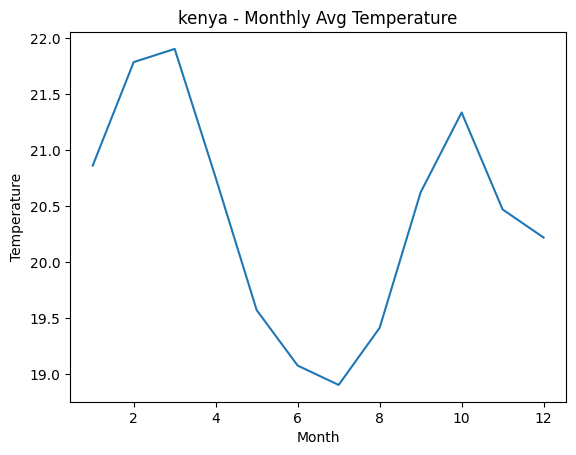

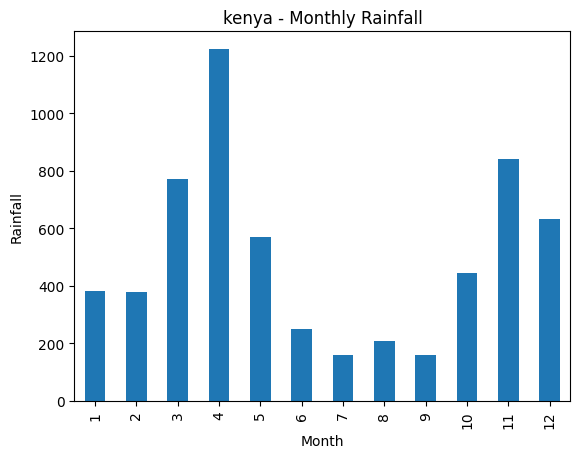


Outliers detected:


t2m             8
t2m_max         3
t2m_min         9
prectotcorr    92
rh2m            6
ws2m            0
dtype: int64


Processing: tanzania

Summary stats:


,t2m,t2m_max,t2m_min,prectotcorr
count,4108.000000,4108.000000,4108.00000,4108.000000
mean,26.802422,29.163493,25.03813,3.740256
std,1.325388,1.371155,1.53544,8.003947
min,22.680000,25.410000,20.03000,0.000000
25%,25.670000,28.090000,23.71000,0.110000
50%,26.990000,29.080000,25.37500,0.640000
75%,27.900000,30.170000,26.31000,3.790000
max,29.970000,33.930000,28.01000,122.650000


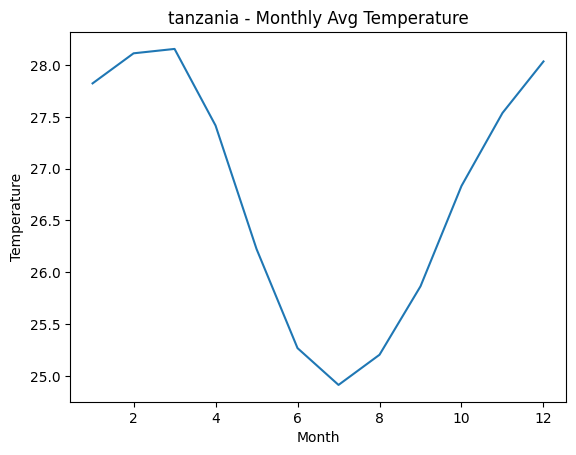

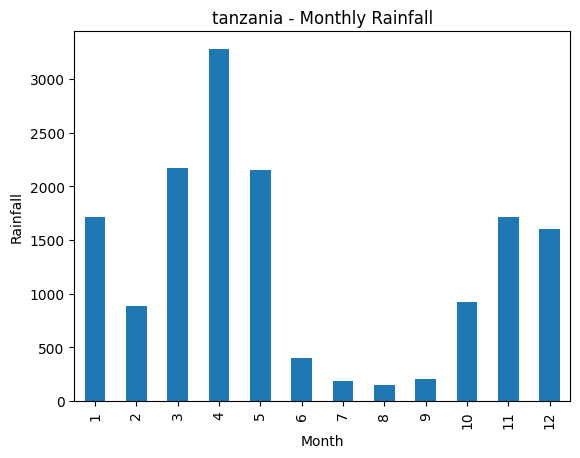


Outliers detected:


t2m             1
t2m_max         2
t2m_min         4
prectotcorr    81
rh2m            2
ws2m            8
dtype: int64


Processing: nigeria

Summary stats:


,t2m,t2m_max,t2m_min,prectotcorr
count,4108.000000,4108.000000,4108.000000,4108.000000
mean,26.656928,28.914667,24.886461,4.213914
std,1.123335,1.294345,1.396727,7.266742
min,21.120000,25.260000,15.170000,0.000000
25%,25.720000,27.920000,24.100000,0.330000
50%,26.820000,28.990000,25.100000,1.840000
75%,27.540000,29.910000,25.860000,5.200000
max,29.290000,32.880000,27.790000,166.100000


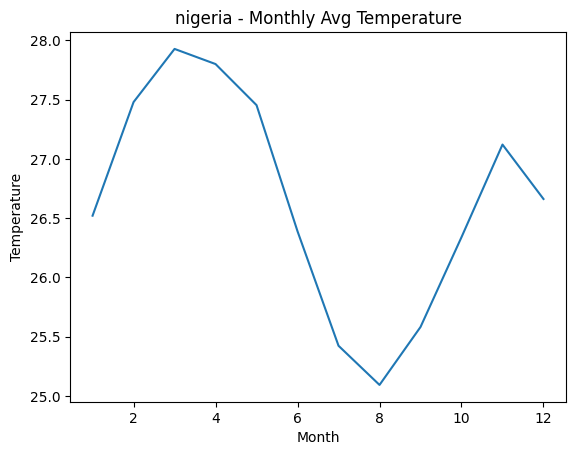

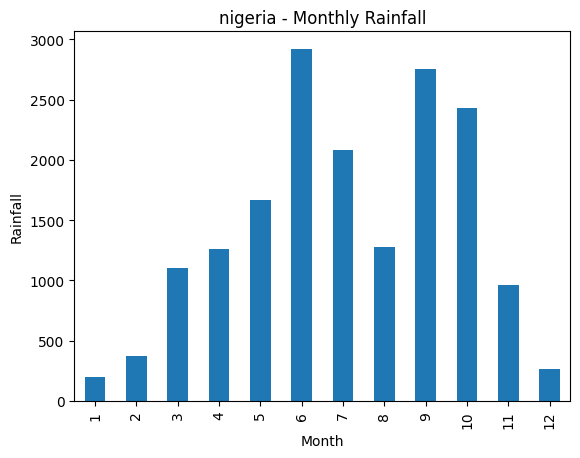


Outliers detected:


t2m             10
t2m_max          1
t2m_min         68
prectotcorr     75
rh2m           128
ws2m             5
dtype: int64


Processing: sudan

Summary stats:


,t2m,t2m_max,t2m_min,prectotcorr
count,4108.000000,4108.000000,4108.000000,4108.000000
mean,28.759007,36.773914,21.508510,0.643875
std,4.681305,4.400065,5.091142,3.057672
min,13.180000,21.040000,5.930000,0.000000
25%,25.560000,33.730000,17.497500,0.000000
50%,29.160000,37.020000,22.890000,0.000000
75%,32.510000,40.330000,25.430000,0.010000
max,37.990000,45.960000,32.170000,66.490000


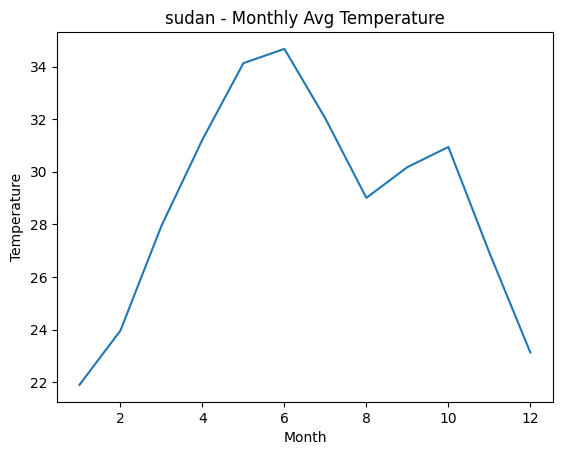

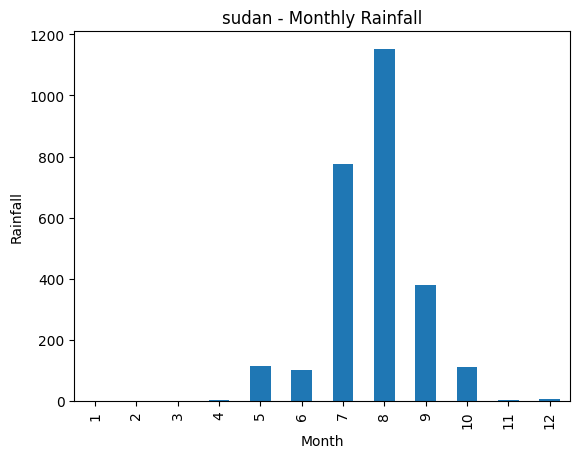


Outliers detected:


t2m             3
t2m_max         6
t2m_min         1
prectotcorr    71
rh2m            3
ws2m            4
dtype: int64

In [92]:
for country in countries:
    print("\n==============================")
    print("Processing:", country)
    print("==============================")

    # -----------------------------
    # LOAD DATA
    # -----------------------------
    file_path = f"../data/{country}.csv"

    try:
        df = pd.read_csv(file_path)
    except FileNotFoundError:
        print(f"❌ File not found: {file_path}")
        continue

    # -----------------------------
    # CLEAN COLUMN NAMES
    # -----------------------------
    df.columns = df.columns.str.strip().str.lower()

    # -----------------------------
    # CREATE DATE COLUMN
    # -----------------------------
    if "year" in df.columns and "doy" in df.columns:
        df["date"] = pd.to_datetime(
            df["year"].astype(str) + df["doy"].astype(str),
            format="%Y%j",
            errors="coerce"
        )
    else:
        print("⚠️ Missing year or doy column")
        continue

    df = df.sort_values("date")

    # -----------------------------
    # HANDLE MISSING VALUES
    # -----------------------------
    df = df[df.isna().mean(axis=1) < 0.3]
    df = df.ffill()

    # -----------------------------
    # FEATURE ENGINEERING
    # -----------------------------
    df["month"] = df["date"].dt.month
    df["year"] = df["date"].dt.year

    # -----------------------------
    # SUMMARY STATISTICS
    # -----------------------------
    cols_basic = ["t2m", "t2m_max", "t2m_min", "prectotcorr"]
    cols_basic = [c for c in cols_basic if c in df.columns]

    print("\nSummary stats:")
    display(df[cols_basic].describe())

    # -----------------------------
    # MONTHLY TEMPERATURE
    # -----------------------------
    if "t2m" in df.columns:
        monthly_temp = df.groupby("month")["t2m"].mean()

        plt.figure()
        monthly_temp.plot(title=f"{country} - Monthly Avg Temperature")
        plt.xlabel("Month")
        plt.ylabel("Temperature")
        plt.show()

    # -----------------------------
    # MONTHLY RAINFALL
    # -----------------------------
    if "prectotcorr" in df.columns:
        monthly_rain = df.groupby("month")["prectotcorr"].sum()

        plt.figure()
        monthly_rain.plot(kind="bar", title=f"{country} - Monthly Rainfall")
        plt.xlabel("Month")
        plt.ylabel("Rainfall")
        plt.show()

    # -----------------------------
    # OUTLIER DETECTION
    # -----------------------------
    cols = ["t2m", "t2m_max", "t2m_min", "prectotcorr", "rh2m", "ws2m"]
    cols = [c for c in cols if c in df.columns]

    if len(cols) > 0:
        z_scores = np.abs(df[cols].apply(zscore))
        outliers = (z_scores > 3).sum()

        print("\nOutliers detected:")
        display(outliers)

In [73]:
# Replace NASA missing values
df.replace(-999, np.nan, inplace=True)

# Check duplicates
print("Duplicates:", df.duplicated().sum())

# Remove duplicates
df.drop_duplicates(inplace=True)

# Missing values count
print(df.isna().sum())

# Missing percentage
missing_percent = (df.isna().sum() / len(df)) * 100
print(missing_percent)

Duplicates: 0
year           0
doy            0
t2m            0
t2m_max        0
t2m_min        0
t2m_range      0
prectotcorr    0
rh2m           0
ws2m           0
ws2m_max       0
ps             0
qv2m           0
date           0
month          0
dtype: int64
year           0.0
doy            0.0
t2m            0.0
t2m_max        0.0
t2m_min        0.0
t2m_range      0.0
prectotcorr    0.0
rh2m           0.0
ws2m           0.0
ws2m_max       0.0
ps             0.0
qv2m           0.0
date           0.0
month          0.0
dtype: float64


In [74]:
df.describe()

,year,doy,t2m,t2m_max,t2m_min,t2m_range,prectotcorr,rh2m,ws2m,ws2m_max,ps,qv2m,date,month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,26.802422,29.163493,25.03813,4.125363,3.740256,77.128038,4.105370,5.189248,100.801130,16.923683,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,22.680000,25.410000,20.03000,0.940000,0.000000,60.060000,1.120000,1.550000,100.150000,11.380000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.670000,28.090000,23.71000,3.330000,0.110000,73.167500,3.410000,4.377500,100.570000,15.340000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,26.990000,29.080000,25.37500,4.220000,0.640000,76.585000,4.190000,5.250000,100.760000,17.220000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,27.900000,30.170000,26.31000,4.940000,3.790000,81.100000,4.830000,5.980000,101.040000,18.420000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,29.970000,33.930000,28.01000,7.590000,122.650000,91.100000,8.400000,11.740000,101.510000,21.510000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.325388,1.371155,1.53544,1.102831,8.003947,5.070501,1.059803,1.215018,0.284461,1.881741,NaN,3.477046


In [75]:
cols = [
    "t2m", "t2m_max", "t2m_min",
    "prectotcorr", "rh2m", "ws2m"
]
from scipy.stats import zscore
import numpy as np

z_scores = np.abs(df[cols].apply(zscore))

outlier_counts = (z_scores > 3).sum()
print(outlier_counts)

t2m             1
t2m_max         2
t2m_min         4
prectotcorr    81
rh2m            2
ws2m            8
dtype: int64


In [76]:
# Drop rows with >30% missing values
# Drop rows with >30% missing values
df = df[df.isna().mean(axis=1) < 0.3]
df["date"] = pd.to_datetime(
    df["year"].astype(str) + df["doy"].astype(str),
    format="%Y%j"
)
df = df.sort_values("date")
# Forward fill (NEW pandas syntax)
df = df.ffill()

In [77]:
df.to_csv("../data/__init__all_clean.csv", index=False)

In [78]:
df["date"] = pd.to_datetime(
    df["year"].astype(str) + df["doy"].astype(str),
    format="%Y%j"
)
df["month"] = df["date"].dt.month


<Axes: title={'center': 'Monthly Average Temperature'}, xlabel='month'>

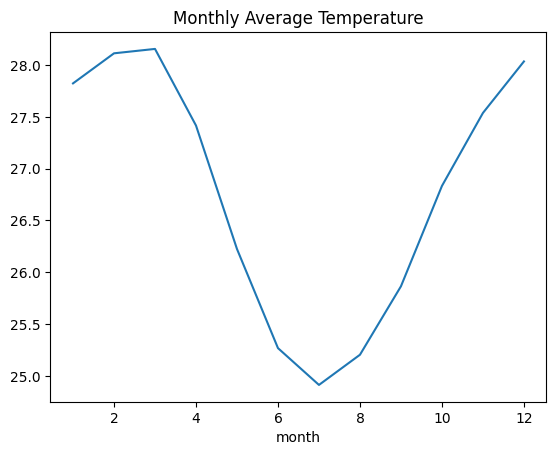

In [79]:
monthly_temp = df.groupby("month")["t2m"].mean()

monthly_temp.plot(title="Monthly Average Temperature")

<Axes: title={'center': 'Monthly Rainfall'}, xlabel='month'>

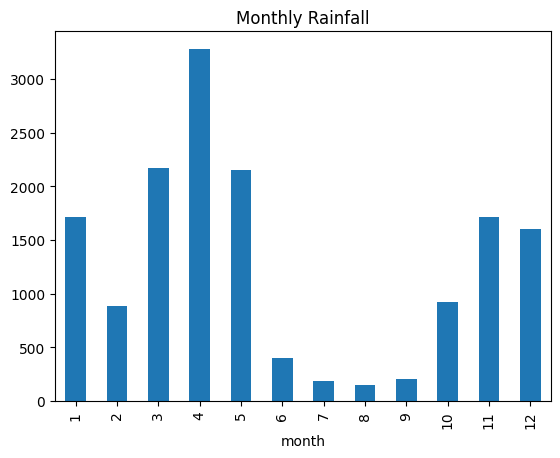

In [80]:
monthly_rain = df.groupby("month")["prectotcorr"].sum()

monthly_rain.plot(kind="bar", title="Monthly Rainfall")


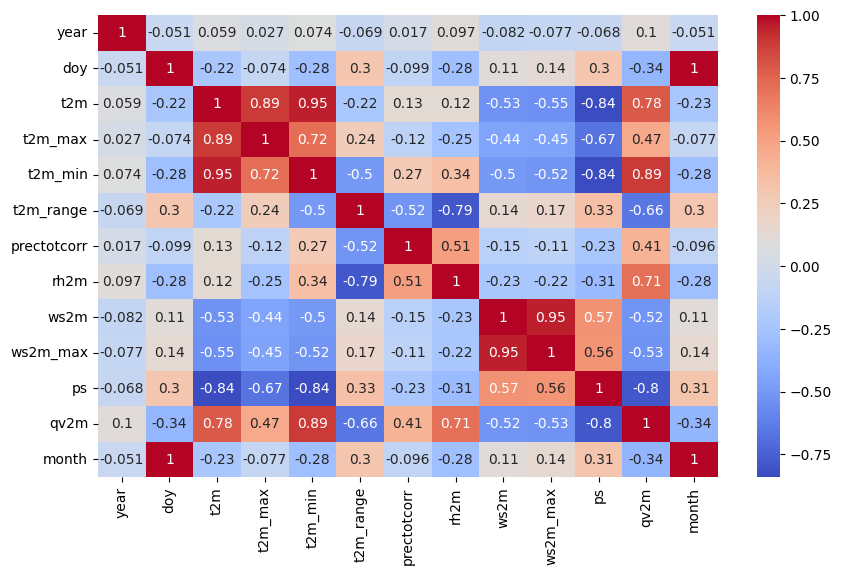

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

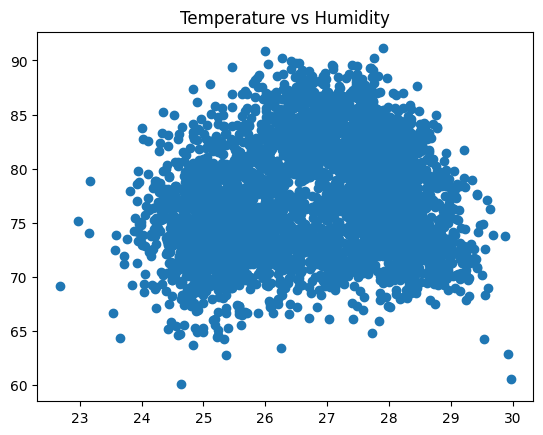

In [81]:
plt.scatter(df["t2m"], df["rh2m"])
plt.title("Temperature vs Humidity")
plt.show()

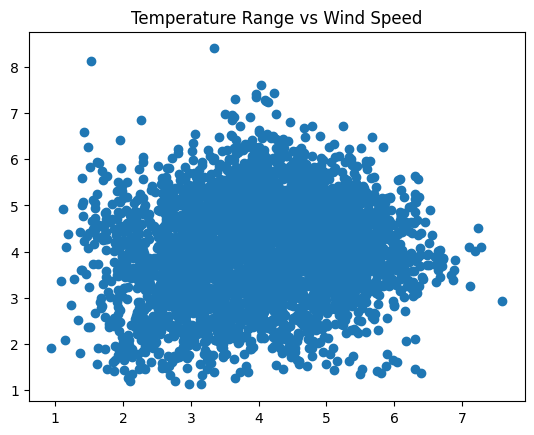

In [82]:
t_range = df["t2m_max"] - df["t2m_min"]

plt.scatter(t_range, df["ws2m"])
plt.title("Temperature Range vs Wind Speed")
plt.show()


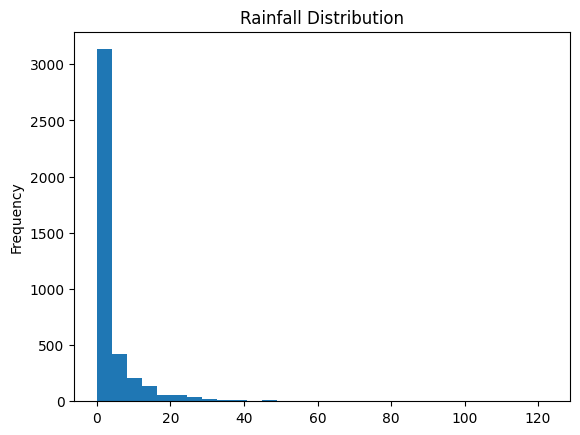

In [83]:
df["prectotcorr"].plot(kind="hist", bins=30, title="Rainfall Distribution")
plt.show()

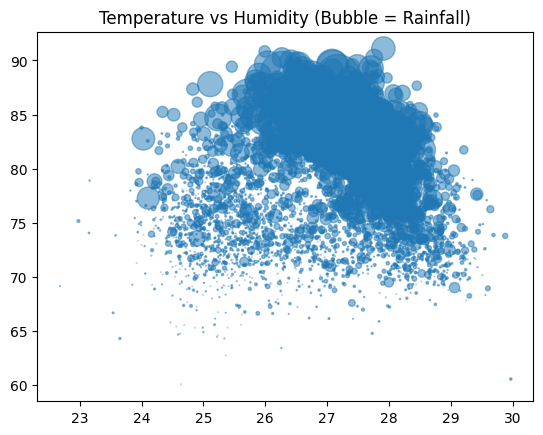

In [85]:
plt.scatter(
    df["t2m"],
    df["rh2m"],
    s=df["prectotcorr"] * 10,
    alpha=0.5
)

plt.title("Temperature vs Humidity (Bubble = Rainfall)")
plt.show()

In [93]:
df.to_csv("../data/ethiopia_clean.csv", index=False)